# Week 03 — Gradient Descent from Scratch

This week I implemented **Gradient Descent**, one of the most important optimization algorithms used in Machine Learning.

Gradient Descent helps models learn by **iteratively updating parameters to minimize a cost function**.

In this notebook I explore:
- What gradient descent is
- The intuition behind cost minimization
- Implementing gradient descent from scratch
- Visualizing convergence
- Understanding the effect of learning rate


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Understanding the Problem

In many machine learning problems, I want to **find parameters that minimize a loss function**.

For example in Linear Regression I try to minimize Mean Squared Error (MSE).

The goal of gradient descent is to find parameter values that reduce this error.

The algorithm works by:
1. Starting with random parameters
2. Computing the gradient (direction of steepest increase)
3. Moving in the opposite direction of the gradient
4. Repeating until convergence


## Creating a Simple Dataset

To understand gradient descent, I first create a simple dataset that follows a linear relationship.

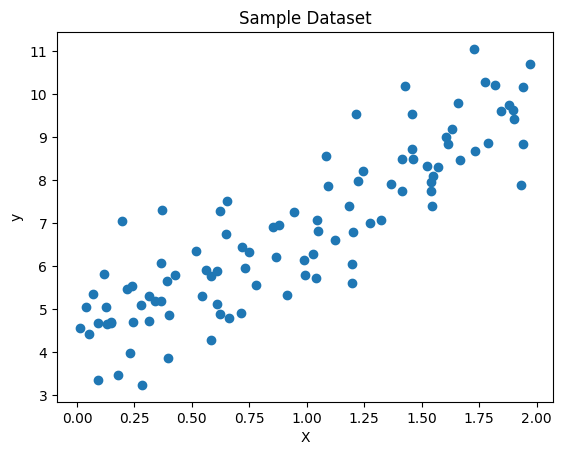

In [2]:
np.random.seed(42)

X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

plt.scatter(X,y)
plt.title('Sample Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

The dataset roughly follows the equation:

y = 4 + 3x + noise

My goal is to use gradient descent to **learn the parameters 4 and 3 automatically**.

## Adding Bias Term

Machine learning models usually include a **bias (intercept) term**.

To represent this mathematically, I add a column of ones to the feature matrix.

In [3]:
X_b = np.c_[np.ones((100,1)), X]

## Defining the Cost Function

I use **Mean Squared Error (MSE)** as the cost function.

MSE measures how far predictions are from the actual values.

The objective of gradient descent is to minimize this cost.

In [4]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    errors = predictions - y
    cost = (1/(2*m)) * np.sum(errors**2)
    return cost

## Implementing Gradient Descent

The parameter update rule is:

theta = theta - learning_rate * gradient

In [5]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradients = (1/m) * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

## Training the Model

In [6]:
theta = np.random.randn(2,1)

learning_rate = 0.1
iterations = 100

theta, cost_history = gradient_descent(X_b, y, theta, learning_rate, iterations)

print('Learned parameters:')
print(theta)

Learned parameters:
[[3.90668931]
 [3.04241987]]


The learned parameters should be close to the true values used to generate the data.

## Visualizing Cost Convergence

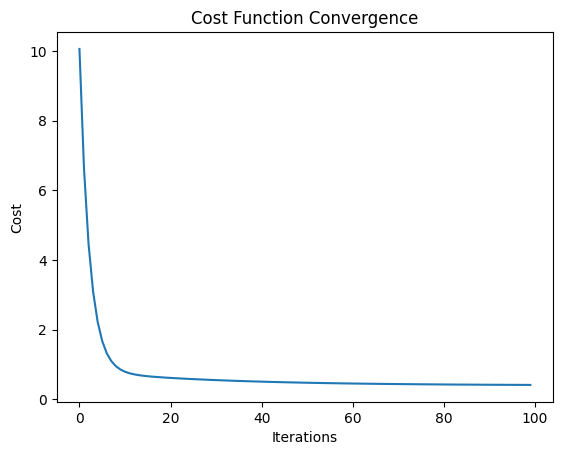

In [7]:
plt.plot(cost_history)
plt.title('Cost Function Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

This plot shows how the cost decreases as gradient descent progresses.

## Effect of Learning Rate

The learning rate controls how large each update step is.

- Too small → very slow learning
- Too large → divergence

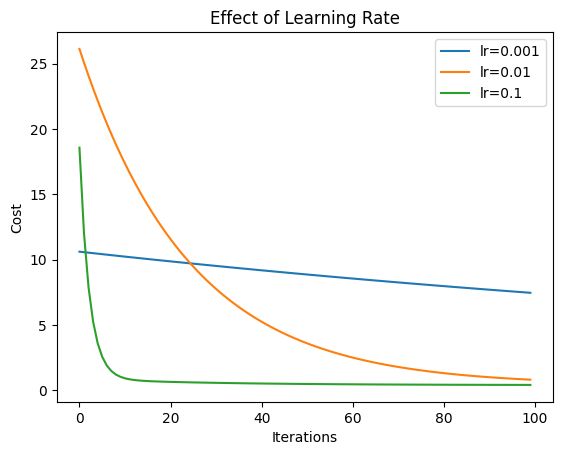

In [8]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    theta = np.random.randn(2,1)
    _, cost_history = gradient_descent(X_b, y, theta, lr, 100)
    plt.plot(cost_history, label=f'lr={lr}')

plt.legend()
plt.title('Effect of Learning Rate')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

## My Reflection

This exercise helped me understand how machine learning models actually learn parameters.

Key takeaways:
- Gradient descent is the core optimization algorithm behind many ML models
- The choice of learning rate is extremely important
- Visualizing cost convergence helps understand the training process

Implementing this from scratch helped me see how optimization works under the hood rather than relying on libraries.